In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
iris
X = iris.data        # (150, 4)
y = iris.target      # (150,)
target_names = iris.target_names
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

selected_n_components = 2 # can be adjusted
lda = LinearDiscriminantAnalysis(n_components=selected_n_components)

X_lda = lda.fit_transform(X, y)

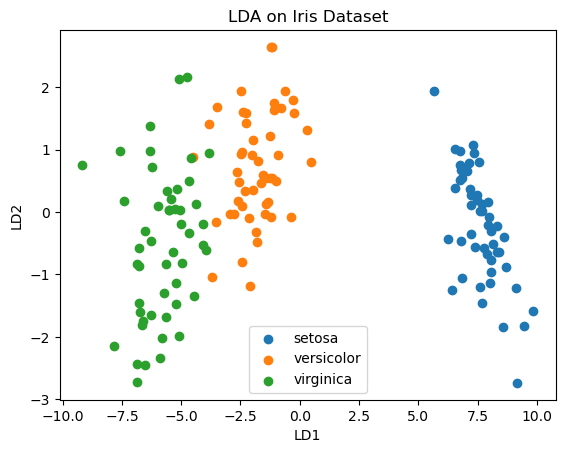

In [5]:
plt.figure()
for label, name in enumerate(target_names):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=name
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA on Iris Dataset")
plt.legend()
plt.show()

In [6]:
print("Discriminant coefficients (w):")
print(lda.scalings_)

Discriminant coefficients (w):
[[ 0.82937764 -0.02410215]
 [ 1.53447307 -2.16452123]
 [-2.20121166  0.93192121]
 [-2.81046031 -2.83918785]]


In [7]:
# Create a Grid of Points
iris = load_iris()
X = iris.data[:, :2]   # first two features
y = iris.target
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

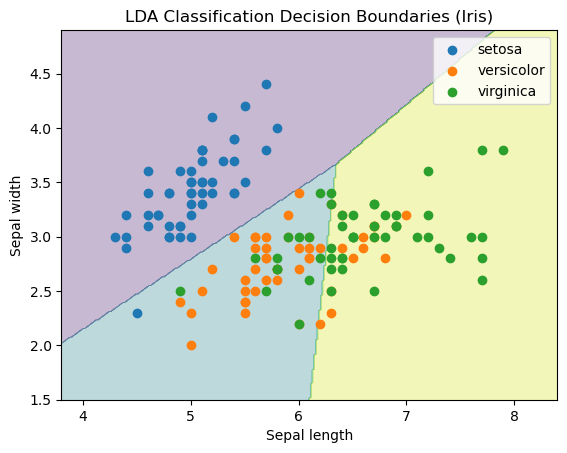

In [8]:
# plot Decision regions
Z = lda.predict(grid)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)

# Training points
for class_label in np.unique(y):
    plt.scatter(
        X[y == class_label, 0],
        X[y == class_label, 1],
        label=iris.target_names[class_label]
    )

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("LDA Classification Decision Boundaries (Iris)")
plt.legend()
plt.show()

### PCA 

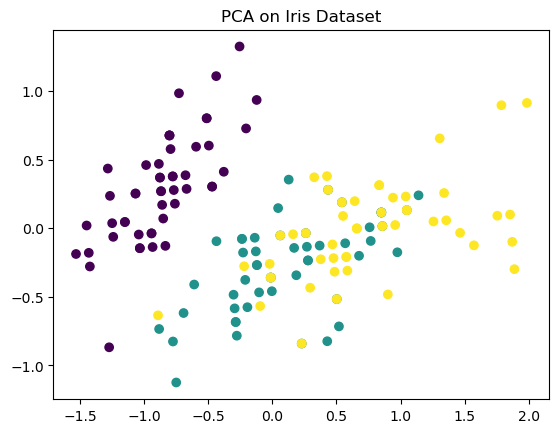

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("PCA on Iris Dataset")
plt.show()

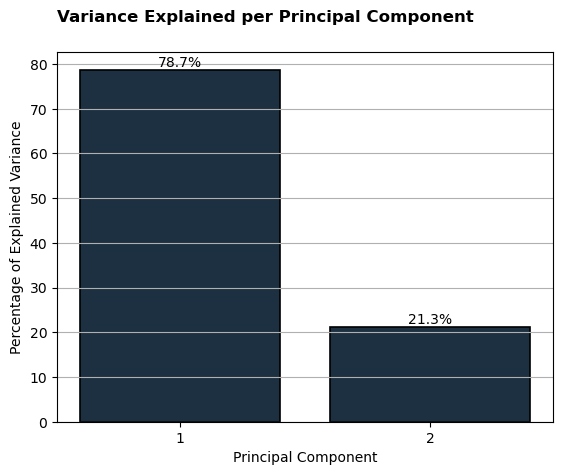

In [10]:
plot_y = [val * 100 for val in pca.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

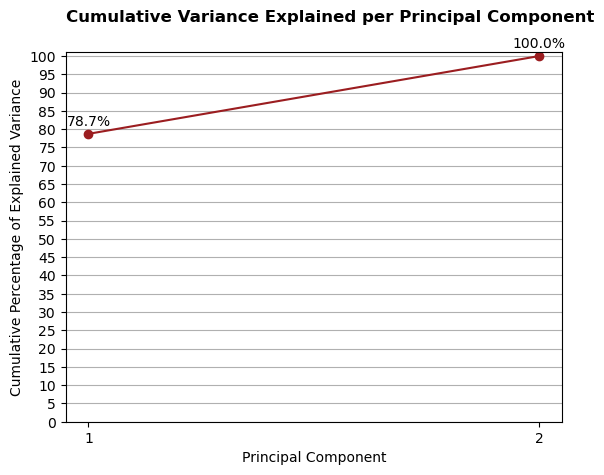

In [11]:
exp_var = [val * 100 for val in pca.explained_variance_ratio_]
plot_y = [sum(exp_var[:i+1]) for i in range(len(exp_var))]
plot_x = range(1, len(plot_y) + 1)

plt.plot(plot_x, plot_y, marker="o", color="#9B1D20")
for x, y in zip(plot_x, plot_y):
    plt.text(x, y + 1.5, f"{y:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Percentage of Explained Variance")
plt.title("Cumulative Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)

plt.yticks(range(0, 101, 5))
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()